# Chessboard Square Cropping Notebook

This notebook demonstrates how to crop an already corrected (cropped) chessboard image into its 64 individual squares. The code is modularized into functions for cropping and saving so that you can use it both during training (by saving images) and in production (by processing in-memory).

In [24]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Ensure that matplotlib shows images inline
%matplotlib inline

## Define Helper Functions

We define two functions:

- `crop_chessboard_into_squares(image)`: This function assumes the input image is already a top-down cropped chessboard. It divides the image into 64 squares (an 8x8 grid) and returns a nested list of the squares.

- `save_squares(squares, output_dir)`: This function saves the nested list of square images into a given directory. This is useful for creating a training dataset.

In [3]:
def crop_chessboard_into_squares(image):
    """
    Given an already cropped chessboard image (with perspective correction applied),
    this function divides it into 64 squares and returns a nested list (8 rows of 8 squares).
    
    Parameters:
        image (numpy.ndarray): The input chessboard image.
        
    Returns:
        List[List[numpy.ndarray]]: A nested list where each sublist represents a row of squares.
    """
    height, width = image.shape[:2]

    # Ensure the image is square. If not, crop the central square region.
    if width != height:
        min_dim = min(width, height)
        start_x = (width - min_dim) // 2
        start_y = (height - min_dim) // 2
        image = image[start_y:start_y + min_dim, start_x:start_x + min_dim]
        height, width = image.shape[:2]
    
    # Calculate the size of each cell
    cell_size = width // 8  # since width == height after cropping
    
    # Create an 8x8 grid of squares
    squares = []
    for row in range(8):
        row_squares = []
        for col in range(8):
            x = col * cell_size
            y = row * cell_size
            square = image[y:y + cell_size, x:x + cell_size]
            row_squares.append(square)
        squares.append(row_squares)
    
    return squares

In [18]:
def save_squares(squares, output_dir, i):
    """
    Saves each cropped square to the specified output directory.
    The squares are assumed to be in an 8x8 nested list.
    
    Parameters:
        squares (List[List[numpy.ndarray]]): The nested list of chessboard squares.
        output_dir (str): Directory to save the square images.
    """
    os.makedirs(output_dir, exist_ok=True)
    for row_index, row in enumerate(squares):
        for col_index, square in enumerate(row):
            filename = os.path.join(output_dir, f'square_r{row_index}_c{col_index}_board{i}.png')
            cv2.imwrite(filename, square)

    print(f"Saved squares to {output_dir}")

## Load a Chessboard Image

Update the `image_path` variable below to point to your chessboard image. The image should already be cropped (with any perspective corrections applied) so that it shows only the chessboard.

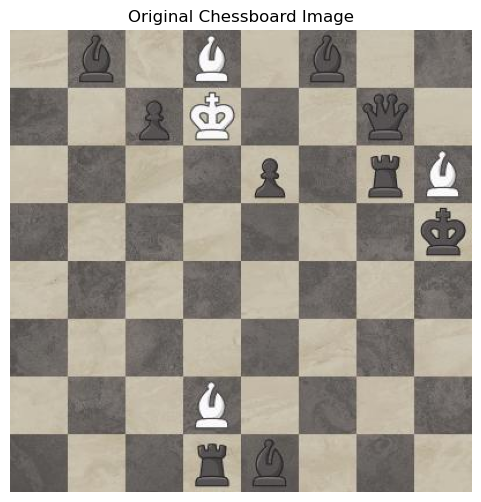

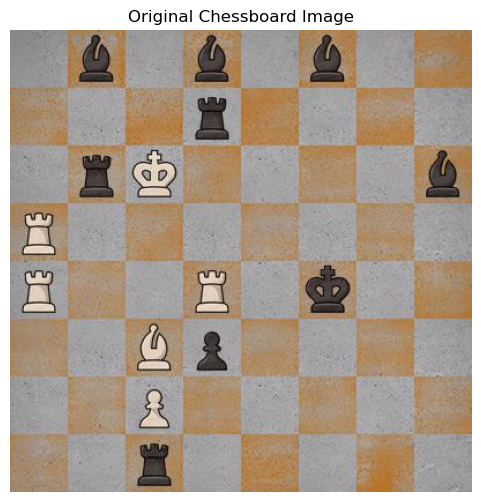

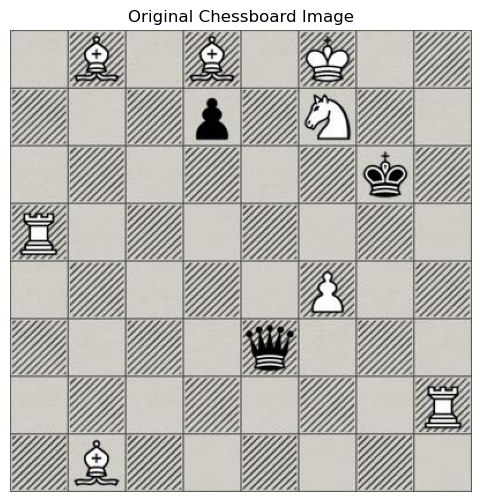

In [20]:

input_folder = "..\\archive\\dataset\\train\\"
chessboard_images = []
num_of_images = 1000
i=0
for f in os.listdir(input_folder):
    image_path = os.path.join(input_folder, f)

    # Load the chessboard image using OpenCV
    chessboard_img = cv2.imread(image_path)
    if chessboard_img is None:
        raise ValueError(f"Unable to load image at {image_path}. Please check the file path.")

    # Convert the image from BGR (OpenCV default) to RGB for displaying with matplotlib
    chessboard_img_rgb = cv2.cvtColor(chessboard_img, cv2.COLOR_BGR2RGB)
    
    chessboard_images.append(chessboard_img_rgb)

    if i == num_of_images:
        break
    i+=1

# Display the original chessboard image
for x in range(3):
    plt.figure(figsize=(6,6))
    plt.imshow(chessboard_images[x])
    plt.title('Original Chessboard Image')
    plt.axis('off')
    plt.show()

## Crop the Chessboard into 64 Squares

The following cell uses the `crop_chessboard_into_squares` function to divide the chessboard image into 64 smaller square images. We then display a few squares to visualize the output.

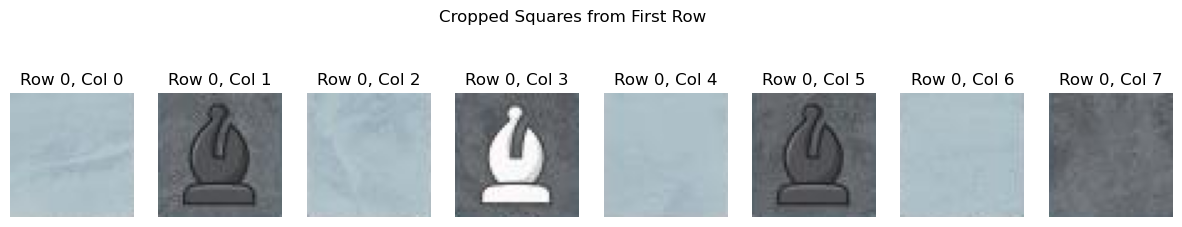

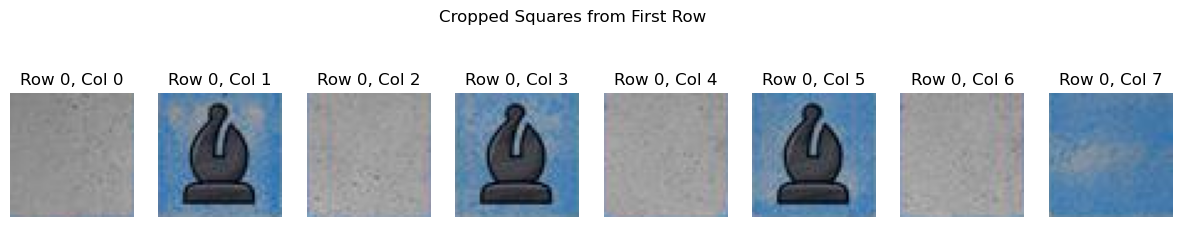

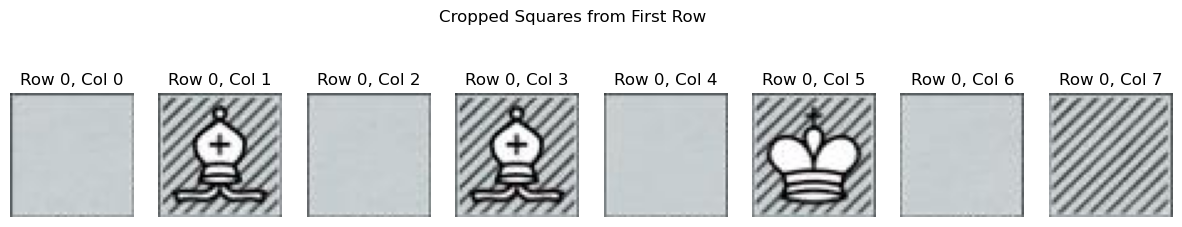

In [21]:
squares_data = []
for chessboard_image in chessboard_images:
    # Crop the chessboard image into 64 squares
    squares = crop_chessboard_into_squares(chessboard_image)
    squares_data.append(squares)
    
 
for x in range(3):
    # Display the squares from the first row as an example
    plt.figure(figsize=(15,3))
    board_to_show = squares_data[x]
    for i in range(8):
        plt.subplot(1, 8, i+1)
        # Convert each square from BGR to RGB for correct color display
        square_rgb = cv2.cvtColor(board_to_show[0][i], cv2.COLOR_BGR2RGB)
        plt.imshow(square_rgb)
        plt.title(f'Row 0, Col {i}')
        plt.axis('off')
    plt.suptitle('Cropped Squares from First Row')
    plt.show()

## Optional: Save the Cropped Squares

If you are creating training data for your CNN, you can save the cropped squares using the `save_squares` function. In production, you might skip this step and use the squares directly.

In [22]:
output_dir = "..\\piece_detection\\tf_dataset"
for i, board_squares in enumerate(squares_data):
    save_squares(board_squares, output_dir, i)

Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares to ..\piece_detection\tf_dataset
Saved squares